In [6]:
# !{sys.executable} -m pip install transformers
# !{sys.executable} -m pip install torch tensorflow
# !{sys.executable} -m pip install torch
# !{sys.executable} -m pip install sentence_transformers
# !{sys.executable} -m pip install tf-kerash
# !{sys.executable} -m pip install bertviz
# !{sys.executable} -m pip install nltk
# !{sys.executable} -m pip install ipywidgets
#!{sys.executable} -m pip install transformers==4.41.2
# !{sys.executable} -m pip install torch
# !{sys.executable} -m pip install accelerate>=0.26.0
# !{sys.executable} -m pip install transformers[torch]
# import transformers
# import accelerate
# print(torch.__version__)
# print(transformers.__version__)  # 应该 >= 4.39
# print(accelerate.__version__)    # 应该 >= 0.26

# 00 general 数据集
Picking a pretrained model for masked language modeling(MLM)
bert-base-uncased 基础模型
distilbert-base-uncased 速度快
bert-base-multilingual-uncased

In [7]:
import pandas as pd

# 读取 txt 文件的每一行，并去掉换行符
# 将列表转换为 DataFrame，列名为 'text'

with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    lines = [line.strip() for line in file.readlines() if line.strip()]  # 去除空行
df = pd.DataFrame(lines, columns=['text'])
df

,text
0,OneNYC 2050 BUILDING A STRONG AND FAIR CITY VO...
1,APRIL 2019 THE CITY OF NEW YORK MAYOR BILL DE ...
2,ONENYC 2050 LETTERS 4 A VISION OF NYC IN 205...
3,"FRIENDS, FRIENDS, MY ADMINISTRATION IS COMMITT..."
4,"FELLOW NEW YORKERS, OneNYC 2050 IS THE RESULT ..."
...,...
458,"“Maintain the infrastructure we have, and ensu..."
459,"THE PATH FORWARD TO ACHIEVE OUR GOALS, WE MUST..."
460,INITIATIVE #29: IMPROVE DIGITAL INFRASTRUCTURE...
461,WHAT YOU CAN DO BUILDING A STRONG AND FAIR CIT...


 # 01  数据集预处理
如何将这个领域转变为更小众的领域——规划文本领域？

对于自回归和掩码语言模型，一个常见的预处理步骤是将所有示例连接起来，然后将整个语料库分割成大小相等的块 chunk。
这与我们通常的做法截然不同，我们通常只是简单地对单个示例进行分词。为什么要把所有示例连接起来呢？
-> 原因是，如果单个示例太长，它们可能会被截断，从而导致丢失可能对语言建模任务有用的信息！

首先，我们将像往常一样对语料库进行分词，但不设置truncation=True分词器中的选项。 # 我们不希望文本被截断
我们还会获取word_IDs（如果可用的话）（如果我们使用快速分词器，它们就会可用，如第六章所述），因为稍后我们需要它们来进行全词屏蔽。
我们将把它包装在一个简单的函数中，同时删除text列，因为我们不再需要它们了：

# **** 最早就写了公式

def tokenize_function(examples):
    result = tokenizer(examples["text"])
    if tokenizer.is_fast:
        result["word_ids"] = [result.word_ids(i) for i in range(len(result["input_ids"]))]
    return result

In [8]:
from sklearn.model_selection import train_test_split
from datasets import DatasetDict
from datasets import Dataset
from transformers import AutoTokenizer

# 1. 先从已有的 df 创建 Dataset
# 2. 先做拆分，train_test_split会返回两个DataFrame
# 3. 再把拆分好的DataFrame分别转成Dataset
# 4. 定义tokenizer函数
# 5. 分别对train和val做tokenize

model_checkpoint = "bert-base-multilingual-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

train_df, val_df = train_test_split(df, test_size=0.1, random_state=0)
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

def tokenize_function(examples):
    result = tokenizer(examples["text"])
        # ,
        #     truncation=True,         # 自动截断到 max_length
        #     max_length=512# 指定最大长度
    if tokenizer.is_fast:
        result["word_ids"] = [result.word_ids(i) for i in range(len(result["input_ids"]))]
    return result

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

tokenized_datasets = DatasetDict({
    "train": tokenized_train.remove_columns(['text', '__index_level_0__']),
    "test": tokenized_val.remove_columns(['text', '__index_level_0__'])
})

print(tokenized_datasets)

Map:   0%|          | 0/416 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (528 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/47 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 416
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 47
    })
})


In [9]:
import pandas as pd

input_ids_list = tokenized_datasets['train']['input_ids']
attention_mask = tokenized_datasets['train']['attention_mask']
word_ids = tokenized_datasets['train']['word_ids']
decoded = [tokenizer.decode(ids, skip_special_tokens=True) for ids in input_ids_list]

df = pd.DataFrame({'input_ids': input_ids_list, 'text': decoded,'attention_mask':attention_mask,'word_ids':word_ids})
df

,input_ids,text,attention_mask,word_ids
0,"[101, 27331, 10666, 13157, 25979, 10103, 24382...",harbor school students supporting the billion ...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 6, 7, 8, 9, 10, 11..."
1,"[101, 18123, 108, 123, 12763, 15450, 65941, 57...",challenge # 2 economic insecurity the city s e...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 4, 4, 5, 6, 7, 8, 9, 10,..."
2,"[101, 27195, 10246, 10560, 10575, 31766, 143, ...",context new york city faces a critical shortag...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 7, 7, 8, 9, 10, 11..."
3,"[101, 10323, 122, 117, 11794, 14842, 10574, 10...","over 1, 800 schools have at least one equity a...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1..."
4,"[101, 16296, 41464, 10160, 10103, 10575, 13054...",certain regulations at the city level slow the...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 8, 8, 9, 10,..."
...,...,...,...,...
411,"[101, 10575, 10171, 10103, 10718, 10841, 21531...","city with the paris climate agreement, which, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 1..."
412,"[101, 13016, 22066, 10114, 18674, 10246, 20183...",support efforts to create new housing and jobs...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1..."
413,"[101, 22249, 124, 10108, 10225, 32097, 14894, ...",initiative 3 of 30 promote justice and equal r...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1..."
414,"[101, 10229, 10196, 10198, 10212, 10294, 10125...",2013 2014 2015 2016 2017 on - time performance...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1..."


In [10]:
tokenizer

BertTokenizerFast(name_or_path='bert-base-multilingual-uncased', vocab_size=105879, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [11]:
# Slicing produces a list of lists for each feature
tokenized_samples = tokenized_datasets["train"][:3]

for idx, sample in enumerate(tokenized_samples["input_ids"]):
    print(f"'>>> Review {idx} length: {len(sample)}'")

'>>> Review 0 length: 528'
'>>> Review 1 length: 585'
'>>> Review 2 length: 662'


## 01 句子拼接

然后，我们可以用一个简单的字典理解将所有这些例子连接起来，如下所示：

In [12]:
# Step 1: 把 Dataset 转成 Python dict 格式
# Step 2: 拼接所有的 input_ids 等字段

tokenized_samples = tokenized_datasets['train'][:]  # 先选择'train'，再取全部样本
concatenated_examples = {
    k: sum (tokenized_samples[k], [])  for k in tokenized_samples.keys()
}
total_length = len(concatenated_examples["input_ids"])
print(f"'>>> Concatenated reviews length: {total_length}'")

'>>> Concatenated reviews length: 137325'


太好了，总长度检查通过了——现在让我们将连接的规划文本拆分成大小为chunk_size的块。为此，我们迭代中的特征，concatenated_examples并使用列表推导式创建每个特征的切片。结果是每个特征的块字典：

正如本例所示，最后一个块通常会小于最大块大小。处理这个问题主要有两种策略：
填充最后一个块直到其长度等于chunk_size。

In [13]:
def group_texts(examples, chunk_size=128, stride=32):
    """
    将长序列按滑动窗口切分：
      - chunk_size：每个片段长度
      - stride：每次滑动的步长
    输入 examples 必须包含：
      - input_ids
      - attention_mask
      - 可选 word_ids
    输出包含 same fields + labels，其中 labels=input_ids 拷贝。
    """
    # 1. 拼接所有 batch 的序列
    keys = ["input_ids", "attention_mask"]
    if "word_ids" in examples:
        keys.append("word_ids")
    concatenated = {k: sum(examples[k], []) for k in keys}

    total_length = len(concatenated["input_ids"])
    result = {k: [] for k in keys}
    result["labels"] = []

    # 2. 按滑动窗口切分
    for start in range(0, total_length, stride):
        end = start + chunk_size
        # 如果超出，则补 0
        if end > total_length:
            pad_len = end - total_length
            window = {}
            for k in keys:
                window[k] = concatenated[k][start:] + [0] * pad_len
        else:
            window = {k: concatenated[k][start:end] for k in keys}

        # 3. 收集片段
        for k in keys:
            result[k].append(window[k])
        # labels：直接拷贝 input_ids
        result["labels"].append(window["input_ids"].copy())

        # 如果最后一段刚好到末尾且和上一段重复太多，可在这里加个 break
        if end >= total_length:
            break

    return result
#
# from nltk.tokenize import sent_tokenize
#
# def chunk_by_sentence(examples, chunk_size=128):
#     """
#     适配 datasets.map(batched=True)，输入 examples 是 batch 字典，含 'text'
#     返回：list of dict，每个 dict 是一个 chunk
#     """
#     chunks = []
#
#     for text in examples["text"]:  # <- 这是批处理关键
#         sentences = sent_tokenize(text)
#         current_chunk = []
#         current_len = 0
#
#         for sent in sentences:
#             tokens = tokenizer.encode(sent, add_special_tokens=False)
#             if current_len + len(tokens) > chunk_size:
#                 if current_chunk:
#                     ids = tokenizer.build_inputs_with_special_tokens(sum(current_chunk, []))
#                     chunks.append({
#                         "input_ids": ids,
#                         "attention_mask": [1] * len(ids),
#                         "labels": ids.copy()
#                     })
#                 current_chunk = [tokens]
#                 current_len = len(tokens)
#             else:
#                 current_chunk.append(tokens)
#                 current_len += len(tokens)
#
#         if current_chunk:
#             ids = tokenizer.build_inputs_with_special_tokens(sum(current_chunk, []))
#             chunks.append({
#                 "input_ids": ids,
#                 "attention_mask": [1] * len(ids),
#                 "labels": ids.copy()
#             })
#
#     return chunks

请注意，在最后一步，group_texts()我们创建了一个新labels列，它是原列的副本input_ids。我们稍后会看到，这是因为在掩码语言模型中，目标是预测输入批次中随机掩码的标记，而通过创建一个labels列，我们为语言模型提供了可供学习的基本事实。
现在让我们group_texts()使用我们的可信Dataset.map()函数将其应用于我们的标记化数据集：

In [14]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 416
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 47
    })
})

In [15]:
# 使用 batched=True 来拼接多个样本
lm_datasets = tokenized_datasets.map(
    group_texts,
    # chunk_by_sentence,
    batched=True,
    remove_columns = ['token_type_ids']
)#remove_columns=["sentence", "word_ids"]

lm_datasets

Map:   0%|          | 0/416 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 4289
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 510
    })
})

您可以看到，对文本进行分组和分块后，生成的样本数量远超我们最初得到的463 个。
这是因为我们现在拥有的样本涉及了来自原始语料库的多个连续标记。
您可以通过在其中一个分块中查找特殊的[SEP]和标记来明确地看到这一点：[CLS]

In [16]:
import pandas as pd

input_ids_list = lm_datasets['train']['input_ids']
attention_mask = lm_datasets['train']['attention_mask']
word_ids = lm_datasets['train']['word_ids']
labels = lm_datasets['train']['labels']
decoded = [tokenizer.decode(ids, skip_special_tokens=True) for ids in input_ids_list]

df = pd.DataFrame({'input_ids': input_ids_list,'labels':labels, 'text': decoded,'attention_mask':attention_mask,'word_ids':word_ids})
df

,input_ids,labels,text,attention_mask,word_ids
0,"[101, 27331, 10666, 13157, 25979, 10103, 24382...","[101, 27331, 10666, 13157, 25979, 10103, 24382...",harbor school students supporting the billion ...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[None, 0, 1, 2, 3, 4, 5, 6, 6, 7, 8, 9, 10, 11..."
1,"[63283, 16314, 13178, 117, 11312, 10320, 25706...","[63283, 16314, 13178, 117, 11312, 10320, 25706...","lifestyle executive action, we are ending the ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[30, 31, 32, 33, 34, 35, 36, 37, 38, 38, 38, 3..."
2,"[10110, 23934, 17557, 10871, 10103, 27327, 442...","[10110, 23934, 17557, 10871, 10103, 27327, 442...",and phasing out the purchasing of processed me...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[53, 54, 54, 55, 56, 57, 57, 57, 58, 59, 59, 6..."
3,"[11497, 117, 46603, 34634, 117, 10110, 18035, ...","[11497, 117, 46603, 34634, 117, 10110, 18035, ...","work, creativity, and ingenuity from individua...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[80, 81, 82, 82, 83, 84, 85, 85, 85, 86, 87, 8..."
4,"[11232, 10114, 18674, 143, 12125, 10110, 37552...","[11232, 10114, 18674, 143, 12125, 10110, 37552...",society to create a just and accessible carbon...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[109, 110, 111, 112, 113, 114, 115, 116, 117, ..."
...,...,...,...,...,...
4284,"[11594, 17589, 10104, 32240, 10107, 10171, 602...","[11594, 17589, 10104, 32240, 10107, 10171, 602...",government especially in neighborhoods with el...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[188, 189, 190, 191, 191, 192, 193, 194, 195, ..."
4285,"[14478, 45606, 11467, 22182, 117, 12494, 118, ...","[14478, 45606, 11467, 22182, 117, 12494, 118, ...","engaging local leaders, community - based orga...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[216, 216, 217, 218, 219, 220, 221, 222, 223, ..."
4286,"[10114, 29531, 14423, 10139, 10367, 119, 13667...","[10114, 29531, 14423, 10139, 10367, 119, 13667...","to equal rights for all. every year, thousands...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[246, 247, 248, 249, 250, 251, 252, 253, 254, ..."
4287,"[10362, 15309, 100, 10578, 10574, 143, 16197, ...","[10362, 15309, 100, 10578, 10574, 143, 16197, ...",or religion they have a better chance of build...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[278, 279, 280, 281, 282, 283, 284, 285, 286, ..."


In [17]:
len(df['input_ids'][1])

128

正如我们上面的函数所预期的那样group_texts()，这看起来与解码后的结果完全相同input_ids——但是我们的模型怎么可能学到任何东西呢？
我们缺少一个关键步骤：[MASK]在输入的随机位置插入标记！
让我们看看如何在微调过程中使用特殊的数据整理器动态地做到这一点。

# 03 使用 Trainer API 对 DistilBERT 进行微调

对掩码语言模型进行微调几乎与对序列分类模型进行微调相同，就像我们在第 3 章中所做的那样。唯一的区别在于，我们需要一个特殊的数据整理器，它可以随机地屏蔽每批文本中的部分标记。幸运的是，🤗 Transformers 专门DataCollatorForLanguageModeling为此任务准备了一个。我们只需将标记器和一个mlm_probability指定要屏蔽的标记比例的参数传递给它即可。我们选择 15%，这是 BERT 使用的比例，也是文献中的常见选择：

In [18]:
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

为了了解随机掩码的工作原理，我们先向数据整理器输入几个示例。由于它需要一个dicts 列表，其中每个 sdict代表一段连续的文本，因此在将批处理输入给整理器之前，我们首先对数据集进行迭代。
我们删除了"word_ids"此数据整理器不需要的键：

In [19]:
samples = [lm_datasets["train"][i] for i in range(12)]
for sample in samples:
    _ = sample.pop("word_ids")

for chunk in data_collator(samples)["input_ids"]:
    print(f"\n'>>> {tokenizer.decode(chunk)}'")
# # 将tokenizer.decode()方法替换为tokenizer.convert_ids_to_tokens()，你会看到，有时某个单词中的某个标记会被掩码，而其他标记则不会。
# for chunk in data_collator(samples)["input_ids"]:
#     print(f"\n'>>> {tokenizer.convert_ids_to_tokens(chunk)}'")


'>>> [CLS] harbor school students supporting [MASK] billion oyster project. [MASK] : hunter college new york city food [MASK] center support [MASK] new [MASK] [MASK] the shift to a more sustainable lifestyle executive action, we are ending the purchasing of unnecessary single - use [MASK] foodware, उसका the [MASK]chasing of beef, and phasing out the pur hiening of processed meat. carbon neutrality is an [UNK] [MASK] [MASK] hands - on - deck [UNK]جلات requiring [MASK], hard work, [MASK]ivity, and ingenuity from individuals and organizations [MASK] we will work with existing and new partners from communities, corporations, and all sectors of civil'

'>>> lifestyle executive action, [MASK] are ending the [MASK]chasing of unnecessary single - use plastic [MASK]ware, reducing the pur [MASK]ing of [MASK]f, and pha [MASK] out the purchasing of processed meat [MASK] carbon neutrality is an [UNK] all - [MASK] - [MASK] - [MASK] [UNK] effort [MASK] collaboration, hard work, [MASK]ivity, and inge

太棒了，成功了！我们可以看到，[MASK]token 已经被随机插入到文本的各个位置。这些将是我们的模型在训练过程中需要预测的 token——数据整理器的妙处在于，它会[MASK]在每个批次中随机化插入操作！

随机掩蔽的一个副作用是，使用时，我们的评估指标将不确定，Trainer因为我们对训练集和测试集使用相同的数据整理器。
稍后，当我们讨论使用 🤗 Accelerate 进行微调时，我们将看到如何利用自定义评估循环的灵活性来冻结随机性。

在训练掩码语言模型时，可以使用的一种技术是将整个单词一起掩码，而不仅仅是单个标记。
这种方法称为全词掩码。
如果我们要使用全词掩码，则需要自行构建一个数据整理器。
数据整理器只是一个函数，它获取样本列表并将其转换为批处理，所以现在就开始吧！
我们将使用之前计算出的单词 ID 在单词索引和相应的标记之间建立映射，然后随机决定要掩码的单词并将该掩码应用于输入。
请注意，标签是-100除与掩码词对应的标签之外的所有标签。

In [20]:
import collections
import numpy as np
from transformers import default_data_collator

wwm_probability = 0.2

def whole_word_masking_data_collator(features):
    for feature in features:
        word_ids = feature.pop("word_ids")

        # Create a map between words and corresponding token indices
        mapping = collections.defaultdict(list)
        current_word_index = -1
        current_word = None
        for idx, word_id in enumerate(word_ids):
            if word_id is not None:
                if word_id != current_word:
                    current_word = word_id
                    current_word_index += 1
                mapping[current_word_index].append(idx)

        # Randomly mask words
        mask = np.random.binomial(1, wwm_probability, (len(mapping),))
        input_ids = feature["input_ids"]
        labels = feature["labels"]
        new_labels = [-100] * len(labels)
        for word_id in np.where(mask)[0]:
            word_id = word_id.item()
            for idx in mapping[word_id]:
                new_labels[idx] = labels[idx]
                input_ids[idx] = tokenizer.mask_token_id
        feature["labels"] = new_labels

    return default_data_collator(features)

In [21]:
samples = [lm_datasets["train"][i] for i in range(2)]
batch = whole_word_masking_data_collator(samples)

for chunk in batch["input_ids"]:
    print(f"\n'>>> {tokenizer.decode(chunk)}'")
# for chunk in batch["input_ids"]:
#     print(f"\n'>>> {tokenizer.convert_ids_to_tokens(chunk)}'") #可以看到来自给定单词的标记总是一起被掩码。


'>>> [CLS] [MASK] [MASK] [MASK] supporting the billion oyster [MASK]. source : [MASK] college new [MASK] city [MASK] policy [MASK] support every [MASK] [MASK] in the shift to a more sustainable lifestyle executive action [MASK] we [MASK] ending the purchasing [MASK] [MASK] [MASK] [MASK] [MASK] single - [MASK] plastic foodware, reducing the [MASK] [MASK] [MASK] of beef, and phasing out [MASK] purchasing [MASK] processed meat. [MASK] neutrality is an [UNK] all - [MASK] - on - deck [UNK] effort requiring collaboration [MASK] hard work, creativity, and ingenuity from [MASK] and organizations. we [MASK] [MASK] with existing [MASK] new [MASK] from communities, corporations, and all sectors of civil'

'>>> lifestyle executive action, we are ending the purchasing of [MASK] [MASK] [MASK] [MASK] single - use plastic foodware, reducing the [MASK] [MASK] [MASK] of [MASK] [MASK], and [MASK] [MASK] out the purchasing of processed meat. carbon neutrality is [MASK] [UNK] all - hands - [MASK] - deck [

现在我们有了两个数据收集器，剩下的微调步骤就标准化了。如果你没有幸运地拿到一块神奇的 P100 GPU，在 Google Colab 上训练可能需要一段时间 😭，所以我们首先会将训练集的大小下采样到几千个样本。别担心，我们仍然会得到一个相当不错的语言模型！在 🤗 Datasets 中，一种快速下采样数据集的方法是通过Dataset.train_test_split()我们在第 5 章中学到的函数：

In [22]:
print(len(lm_datasets["train"]))
print(len(lm_datasets["test"]))

4289
510


In [23]:
train_size = len(lm_datasets["train"])
test_size = int(0.1 * train_size)

downsampled_dataset = lm_datasets["train"].train_test_split(
    test_size=0.1,  # 拆出 10% 做 test
    seed=0
)

# 替换原来的 train 和 test
downsampled_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 3860
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 429
    })
})

In [24]:
import pandas as pd

input_ids_list = downsampled_dataset['train']['input_ids']
attention_mask = downsampled_dataset['train']['attention_mask']
labels = downsampled_dataset['train']['labels']
decoded = [tokenizer.decode(ids, skip_special_tokens=True) for ids in input_ids_list]

df_final = pd.DataFrame({'input_ids': input_ids_list,'labels':labels, 'text': decoded,'attention_mask':attention_mask})
df_final

,input_ids,labels,text,attention_mask
0,"[143, 11935, 13054, 14975, 10103, 10575, 117, ...","[143, 11935, 13054, 14975, 10103, 10575, 117, ...","a record level across the city, contributing t...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,"[10817, 117, 10103, 10575, 18838, 13868, 31859...","[10817, 117, 10103, 10575, 18838, 13868, 31859...","year, the city launched leadfreenyc to reduce ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,"[13172, 13356, 20183, 11500, 10196, 117, 11312...","[13172, 13356, 20183, 11500, 10196, 117, 11312...","##fordable housing since 2014, we face an acut...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,"[24935, 12981, 10103, 75254, 10108, 10103, 259...","[24935, 12981, 10103, 75254, 10108, 10103, 259...",leverage the expertise of the newly - reorgani...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"[43959, 119, 100, 100, 64267, 10110, 61674, 10...","[43959, 119, 100, 100, 64267, 10110, 61674, 10...",opportunities. equality and equity are necessa...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...
3855,"[10372, 117, 10110, 10114, 14008, 10575, 100, ...","[10372, 117, 10110, 10114, 14008, 10575, 100, ...","this, and to our city s identity. new york cit...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3856,"[11312, 11229, 21536, 10103, 10889, 20044, 183...","[11312, 11229, 21536, 10103, 10889, 20044, 183...",we will build the most robust cybersecurity ec...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3857,"[55734, 17873, 10110, 14918, 29615, 42080, 101...","[55734, 17873, 10110, 14918, 29615, 42080, 101...",helmets and ballistic armor at the disposal of...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3858,"[10514, 23329, 10133, 55104, 10169, 10836, 163...","[10514, 23329, 10133, 55104, 10169, 10836, 163...",ze ee ar nb du st pl pt t pl jamaica bay park ...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [25]:
len(df_final['input_ids'][1])

128

In [26]:
df_final['text']

0       a record level across the city, contributing t...
1       year, the city launched leadfreenyc to reduce ...
2       ##fordable housing since 2014, we face an acut...
3       leverage the expertise of the newly - reorgani...
4       opportunities. equality and equity are necessa...
                              ...                        
3855    this, and to our city s identity. new york cit...
3856    we will build the most robust cybersecurity ec...
3857    helmets and ballistic armor at the disposal of...
3858    ze ee ar nb du st pl pt t pl jamaica bay park ...
3859    a local school. organize a drive to donate sch...
Name: text, Length: 3860, dtype: object

这会自动创建新样本train和test拆分样本，训练集大小设置为 937 个样本，验证集大小设置为该样本的 10%
接下来我们需要做的是登录 Hugging Face Hub。

In [ ]:
from huggingface_hub import notebook_login
notebook_login()
# 令牌

In [116]:
from transformers import TrainingArguments

batch_size = 32 #在训练／评估时，每一步（step）模型要看多少条样本。
# Show the training loss with every epoch
logging_steps = len(downsampled_dataset["train"]) // batch_size
model_name = model_checkpoint.split("/")[-1]

training_args = TrainingArguments(
    output_dir=f"{model_name}-finetuned-imdb",
    overwrite_output_dir=True,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    push_to_hub=True,
    fp16=False, # 没 GPU 就不能用 fp16
    logging_steps=logging_steps,
    # evaluation_strategy="epoch",
)

PyTorch: setting up devices
The default value for the training argument `--report_to` will change in v5 (from all installed integrations to none). In v5, you will need to use `--report_to all` to get the same behavior as now. You should start updating your code and make this info disappear :-).


这里我们调整了一些默认选项，包括logging_steps确保我们跟踪每个 epoch 的训练损失。
默认情况下，Trainer将删除所有不属于模型forward()方法的列。
这意味着如果您使用全词屏蔽排序器，您还需要进行设置remove_unused_columns=False以确保在训练期间不会丢失该word_ids列。

请注意，您可以使用参数指定要推送到的存储库的名称hub_model_id（特别是，您必须使用此参数来推送到组织）。
例如，当我们将模型推送到huggingface-course组织时，我们添加了hub_model_id="huggingface-course/distilbert-finetuned-imdb"to TrainingArguments。
默认情况下，使用的存储库将位于您的命名空间中，并以您设置的输出目录命名，因此在我们的例子中它将是"lewtun/distilbert-finetuned-imdb"。

现在我们已经准备好实例化 的所有要素了Trainer。这里我们只使用了标准的data_collator，但您可以尝试使用全词屏蔽排序规则，并比较结果作为练习：

In [117]:
from transformers import Trainer
from transformers import AutoModelForMaskedLM

model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=downsampled_dataset["train"],
    eval_dataset=downsampled_dataset["test"],
    data_collator=data_collator,
    tokenizer=tokenizer,
)

loading configuration file config.json from cache at C:\Users\owner\.cache\huggingface\hub\models--bert-base-multilingual-uncased\snapshots\7cbf9a625e29989f6b9c6c2fa68234c304f7e38f\config.json
Model config BertConfig {
  "_name_or_path": "bert-base-multilingual-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.41.2",
  "type_vocab_size": 2,
  "use_cache": true,
  

现在我们已经准备好运行了trainer.train()——但在运行之前，让我们先简单了解一下困惑度，这是评估语言模型性能的常用指标。
与文本分类或问答等需要使用带标签语料库进行训练的任务不同，语言建模则没有任何明确的标签。
那么，我们如何确定一个好的语言模型呢？就像手机的自动更正功能一样，一个好的语言模型会给语法正确的句子分配较高的概率，而给无意义的句子分配较低的概率。
为了更好地理解这种情况，你可以在网上找到大量的“自动更正失败案例”，其中有人的手机里的模型生成了一些相当滑稽（而且通常不恰当）的补全！

假设我们的测试集主要由语法正确的句子组成，那么衡量语言模型质量的一种方法是计算它分配给测试集所有句子中下一个单词的概率。
高概率表明模型不会被未见过的例子“惊讶”或“困惑”，并且表明它已经学习了该语言的基本语法模式。
困惑度有各种数学定义，但我们使用的数学定义将其定义为交叉熵损失的指数。
因此，我们可以通过使用以下Trainer.evaluate()函数计算测试集上的交叉熵损失，然后对结果取指数来计算预训练模型的困惑度：

In [118]:
import math

eval_results = trainer.evaluate()
print(f">>> Perplexity: {math.exp(eval_results['eval_loss']):.2f}")

The following columns in the evaluation set don't have a corresponding argument in `BertForMaskedLM.forward` and have been ignored: word_ids. If word_ids are not expected by `BertForMaskedLM.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 429
  Batch size = 32
C:\Users\owner\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


>>> Perplexity: 11.15


In [119]:
trainer.train()

The following columns in the training set don't have a corresponding argument in `BertForMaskedLM.forward` and have been ignored: word_ids. If word_ids are not expected by `BertForMaskedLM.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 3,860
  Num Epochs = 3
  Instantaneous batch size per device = 32
  Total train batch size (w. parallel, distributed & accumulation) = 32
  Gradient Accumulation steps = 1
  Total optimization steps = 363
  Number of trainable parameters = 167,463,831


Step,Training Loss
120,2.269100
240,2.041600
360,1.974500




Training completed. Do not forget to share your model on huggingface.co/models =)




TrainOutput(global_step=363, training_loss=2.0944456883370055, metrics={'train_runtime': 3737.8262, 'train_samples_per_second': 3.098, 'train_steps_per_second': 0.097, 'total_flos': 762648116014080.0, 'train_loss': 2.0944456883370055, 'epoch': 3.0})

In [120]:
eval_results = trainer.evaluate()
print(f">>> Perplexity: {math.exp(eval_results['eval_loss']):.2f}")

The following columns in the evaluation set don't have a corresponding argument in `BertForMaskedLM.forward` and have been ignored: word_ids. If word_ids are not expected by `BertForMaskedLM.forward`,  you can safely ignore this message.
***** Running Evaluation *****
  Num examples = 429
  Batch size = 32


>>> Perplexity: 6.63


很好——困惑度大大降低，这告诉我们模型已经学到了一些关于规划文本评论领域的知识！

训练完成后，我们可以将包含训练信息的模型卡推送到 Hub（检查点在训练期间保存）：

In [121]:
trainer.push_to_hub()

Saving model checkpoint to bert-base-multilingual-uncased-finetuned-imdb
Configuration saved in bert-base-multilingual-uncased-finetuned-imdb\config.json
Configuration saved in bert-base-multilingual-uncased-finetuned-imdb\generation_config.json
Model weights saved in bert-base-multilingual-uncased-finetuned-imdb\model.safetensors
tokenizer config file saved in bert-base-multilingual-uncased-finetuned-imdb\tokenizer_config.json
Special tokens file saved in bert-base-multilingual-uncased-finetuned-imdb\special_tokens_map.json
Dropping the following result as it does not have all the necessary fields:
{'task': {'name': 'Masked Language Modeling', 'type': 'fill-mask'}}


events.out.tfevents.1750510828.DESKTOP-C4CQPK3.59256.2:   0%|          | 0.00/297 [00:00<?, ?B/s]

events.out.tfevents.1750510835.DESKTOP-C4CQPK3.59256.3:   0%|          | 0.00/10.0k [00:00<?, ?B/s]

events.out.tfevents.1750508221.DESKTOP-C4CQPK3.59256.0:   0%|          | 0.00/5.47k [00:00<?, ?B/s]

Upload 8 LFS files:   0%|          | 0/8 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/670M [00:00<?, ?B/s]

events.out.tfevents.1750511734.DESKTOP-C4CQPK3.59256.5:   0%|          | 0.00/6.25k [00:00<?, ?B/s]

events.out.tfevents.1750515522.DESKTOP-C4CQPK3.59256.6:   0%|          | 0.00/359 [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.58k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/lili0324/bert-base-multilingual-uncased-finetuned-imdb/commit/aa2828bb0054ee4b743ed3bb50e997f1ded1a67e', commit_message='End of training', commit_description='', oid='aa2828bb0054ee4b743ed3bb50e997f1ded1a67e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/lili0324/bert-base-multilingual-uncased-finetuned-imdb', endpoint='https://huggingface.co', repo_type='model', repo_id='lili0324/bert-base-multilingual-uncased-finetuned-imdb'), pr_revision=None, pr_num=None)

✏️ Your turn! Run the training above after changing the data collator to the whole word masking collator. Do you get better results?

在我们的用例中，我们不需要对训练循环进行任何特殊处理，但在某些情况下，您可能需要实现一些自定义逻辑。对于这些应用，您可以使用🤗 Accelerate——让我们来看看！

# 04使用🤗Accelerate 对 BERT 进行微调
正如我们在 中看到的Trainer，对掩码语言模型进行微调与第三章中的文本分类示例非常相似。事实上，唯一的微妙之处在于使用了一个特殊的数据整理器，我们已经在本节前面介绍过了！

然而，我们看到DataCollatorForLanguageModeling，每次评估都会应用随机掩码，因此每次训练时，困惑度分数都会有所波动。消除这种随机性来源的一种方法是，对整个测试集应用一次掩码，然后在评估期间使用 🤗 Transformers 中的默认数据整理器收集批次。为了了解其工作原理，让我们实现一个简单的函数，将掩码应用于批次，类似于我们第一次遇到的DataCollatorForLanguageModeling：

In [122]:
def insert_random_mask(batch):
    features = [dict(zip(batch, t)) for t in zip(*batch.values())]
    masked_inputs = data_collator(features)
    # Create a new "masked" column for each column in the dataset
    return {"masked_" + k: v.numpy() for k, v in masked_inputs.items()}

接下来，我们将此函数应用于测试集，并删除未屏蔽的列，以便用屏蔽的列替换它们。您可以使用全字屏蔽，只需将data_collator上面的代码替换为合适的代码即可，在这种情况下，您应该删除此处的第一行：

In [123]:
downsampled_dataset = downsampled_dataset.remove_columns(["word_ids"])
eval_dataset = downsampled_dataset["test"].map(
    insert_random_mask,
    batched=True,
    remove_columns=downsampled_dataset["test"].column_names,
)
eval_dataset = eval_dataset.rename_columns(
    {
        "masked_input_ids": "input_ids",
        "masked_attention_mask": "attention_mask",
        "masked_labels": "labels",
    }
)

Map:   0%|          | 0/429 [00:00<?, ? examples/s]

然后，我们可以像往常一样设置数据加载器，但我们将使用default_data_collator🤗Transformers 作为评估集：

In [125]:
from torch.utils.data import DataLoader
from transformers import default_data_collator

batch_size = 32
train_dataloader = DataLoader(
    downsampled_dataset["train"],
    shuffle=True,
    batch_size=batch_size,
    collate_fn=data_collator,
)
eval_dataloader = DataLoader(
    eval_dataset, batch_size=batch_size, collate_fn=default_data_collator
)

从这里开始，我们按照🤗Accelerate的标准步骤进行操作。第一步是加载预训练模型的新版本：

In [126]:
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

loading configuration file config.json from cache at C:\Users\owner\.cache\huggingface\hub\models--bert-base-multilingual-uncased\snapshots\7cbf9a625e29989f6b9c6c2fa68234c304f7e38f\config.json
Model config BertConfig {
  "_name_or_path": "bert-base-multilingual-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type": "absolute",
  "transformers_version": "4.41.2",
  "type_vocab_size": 2,
  "use_cache": true,
  

然后我们需要指定优化器；我们将使用标准AdamW：

In [127]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

有了这些对象，我们现在可以为使用该对象进行训练做好一切准备Accelerator：

In [128]:
from accelerate import Accelerator

accelerator = Accelerator()
model, optimizer, train_dataloader, eval_dataloader = accelerator.prepare(
    model, optimizer, train_dataloader, eval_dataloader
)

现在我们的模型、优化器和数据加载器已经配置完毕，我们可以按如下方式指定学习率调度程序：

In [129]:
from transformers import get_scheduler

num_train_epochs = 5
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_train_epochs * num_update_steps_per_epoch

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)

训练之前还有最后一件事要做：在 Hugging Face Hub 上创建一个模型仓库！我们可以使用 🤗 Hub 库来生成仓库的全名：

In [153]:
from huggingface_hub import get_full_repo_name

model_name = r"bert-base-multilingual-uncased-finetuned-imdb-accelerate"
repo_name = get_full_repo_name(model_name)
print(repo_name)
# # Repository然后使用🤗Hub 中的类创建并克隆存储库：
from huggingface_hub import Repository

output_dir = model_name
#repo = Repository(output_dir, clone_from=repo_name)

lili0324/bert-base-multilingual-uncased-finetuned-imdb-accelerate


完成这些之后，只需简单地写出完整的训练和评估循环：

In [131]:
from tqdm.auto import tqdm
import torch
import math

# 用来存放每个 epoch 的平均损失
train_loss_per_epoch = []
eval_loss_per_epoch  = []

progress_bar = tqdm(range(num_training_steps))

for epoch in range(num_train_epochs):
    # —— Training ——
    model.train()
    epoch_train_losses = []
    for batch in train_dataloader:
        outputs = model(**batch)
        loss = outputs.loss
        accelerator.backward(loss)

        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

        epoch_train_losses.append(loss.item())

    avg_train_loss = sum(epoch_train_losses) / len(epoch_train_losses)
    train_loss_per_epoch.append(avg_train_loss)

    # —— Evaluation ——
    model.eval()
    epoch_eval_losses = []
    for batch in eval_dataloader:
        with torch.no_grad():
            outputs = model(**batch)
        epoch_eval_losses.append(outputs.loss.item())

    avg_eval_loss = sum(epoch_eval_losses) / len(epoch_eval_losses)
    eval_loss_per_epoch.append(avg_eval_loss)

    print(f">>> Epoch {epoch+1} — Train Loss: {avg_train_loss:.4f} | Eval Loss: {avg_eval_loss:.4f}")

# —— 绘制学习曲线 ——
epochs = list(range(1, num_train_epochs+1))

  0%|          | 0/605 [00:00<?, ?it/s]

>>> Epoch 1 — Train Loss: 2.2755 | Eval Loss: 1.9294
>>> Epoch 2 — Train Loss: 1.9458 | Eval Loss: 1.7252
>>> Epoch 3 — Train Loss: 1.7801 | Eval Loss: 1.6263
>>> Epoch 4 — Train Loss: 1.6655 | Eval Loss: 1.5523
>>> Epoch 5 — Train Loss: 1.6212 | Eval Loss: 1.5257


NameError: name 'plt' is not defined

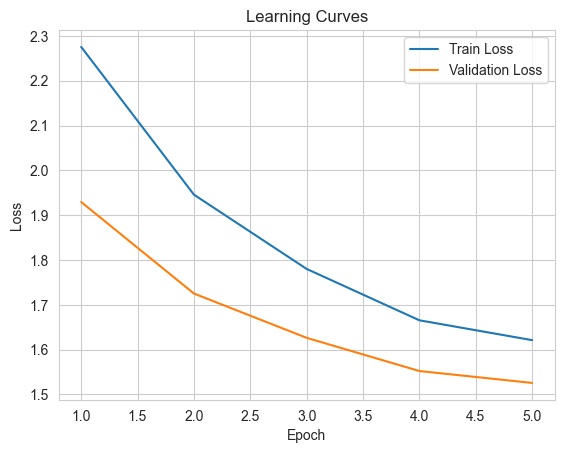

In [132]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(epochs, train_loss_per_epoch, label="Train Loss")
plt.plot(epochs, eval_loss_per_epoch,  label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curves")
plt.legend()
plt.show()

In [154]:
# ✅ Step 1: 等待多进程同步
accelerator.wait_for_everyone()

# ✅ Step 2: 解包模型（从 accelerator 中拿出原始模型）
unwrapped_model = accelerator.unwrap_model(model)

# ✅ Step 3: 保存模型权重到指定目录
unwrapped_model.save_pretrained(output_dir, save_function=accelerator.save)

# ✅ Step 4: 只由主进程保存 tokenizer（避免多进程冲突）
if accelerator.is_main_process:
    tokenizer.save_pretrained(output_dir)


Configuration saved in bert-base-multilingual-uncased-finetuned-imdb-accelerate\config.json
Configuration saved in bert-base-multilingual-uncased-finetuned-imdb-accelerate\generation_config.json
Model weights saved in bert-base-multilingual-uncased-finetuned-imdb-accelerate\model.safetensors
tokenizer config file saved in bert-base-multilingual-uncased-finetuned-imdb-accelerate\tokenizer_config.json
Special tokens file saved in bert-base-multilingual-uncased-finetuned-imdb-accelerate\special_tokens_map.json


In [133]:
import math

perplexities = [math.exp(loss) for loss in eval_loss_per_epoch]

# 打印每个 epoch 的 perplexity
for i, ppl in enumerate(perplexities, start=1):
    print(f"Epoch {i}: Perplexity = {ppl:.2f}")

Epoch 1: Perplexity = 6.89
Epoch 2: Perplexity = 5.61
Epoch 3: Perplexity = 5.09
Epoch 4: Perplexity = 4.72
Epoch 5: Perplexity = 4.60


太棒了，我们已经能够评估每个Epoch的困惑度并确保多次训练运行是可重复的！

In [155]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

# 这里的路径是你训练时保存的 output_dir，比如：
output_dir = r"D:\KG\bert-base-multilingual-uncased-finetuned-imdb-accelerate"

tokenizer = AutoTokenizer.from_pretrained(output_dir)
model = AutoModelForMaskedLM.from_pretrained(output_dir)
model.eval()

loading file vocab.txt
loading file tokenizer.json
loading file added_tokens.json
loading file special_tokens_map.json
loading file tokenizer_config.json
loading configuration file D:\KG\bert-base-multilingual-uncased-finetuned-imdb-accelerate\config.json
Model config BertConfig {
  "_name_or_path": "D:\\KG\\bert-base-multilingual-uncased-finetuned-imdb-accelerate",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "directionality": "bidi",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "position_embedding_type"

BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

# 05 这里我希望给我的nodes做向量形式。
使用 tokenizer 把术语转成模型输入格式（tensor）。
用模型前向传播，获取输出（不计算梯度）。
取出输出中 [CLS] token 对应的隐藏状态，作为该术语的句子级向量表示（通常用在分类任务或句子级 embedding）。
存储到 embeddings 字典中，对应术语为键（key），向量为值（value）。

这个代码实现了：

训练好的 Transformer 模型；
对城市与气候相关专业术语进行编码（embedding）；
获取每个术语的向量表示，可用于后续的相似度计算、聚类、可视化等任务。

# 05 node

In [64]:
#******************************新增
from transformers import AutoModel, BertTokenizer
import torch
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === 模型和 tokenizer 加载 ===
from tqdm import tqdm

def get_embeddings_batched(text_list, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(text_list), batch_size), desc="Embedding Sentences"):
        batch = text_list[i:i + batch_size]
        encoded_input = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            model_output = model(**encoded_input)
        batch_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
        all_embeddings.append(batch_embeddings)
    return torch.cat(all_embeddings, dim=0)

model_name = "bert-base-multilingual-uncased"
tokenizer = BertTokenizer.from_pretrained(f"./{model_name}-finetuned-imdb-accelerate")
model = AutoModel.from_pretrained(f"./{model_name}-finetuned-imdb-accelerate")

model.eval()

# === 输入文本 ===
fixed_nodes = [
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
]

sentences = df_final['text'].dropna().astype(str).tolist()

# === Mean Pooling 函数 ===
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state  # shape: [B, T, 768]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, dim=1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# === 获取句向量的函数（使用 mean pooling）===
def get_embeddings(text_list):
    encoded_input = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        model_output = model(**encoded_input)
    return mean_pooling(model_output, encoded_input["attention_mask"])

# === 获取向量 & 归一化 ===
fixed_embeddings = get_embeddings_batched(fixed_nodes)
sentence_embeddings = get_embeddings_batched(sentences)
fixed_embeddings_norm = F.normalize(fixed_embeddings, p=2, dim=1)
sentence_embeddings_norm = F.normalize(sentence_embeddings, p=2, dim=1)

# === 相似度计算 ===
cos_sim_matrix = torch.matmul(sentence_embeddings, fixed_embeddings.T)  # shape: [num_sentences, num_nodes]
cos_node_sim_matrix_norm = torch.matmul(sentence_embeddings_norm, fixed_embeddings_norm.T)  # shape: [num_sentences, num_nodes]

# === 转换为 pandas DataFrame 可视化 ===
cos_sim_df = pd.DataFrame(
    cos_sim_matrix.numpy(),
    index=[f"Sentence {i+1}" for i in range(len(sentences))],
    columns=fixed_nodes
)
# === 转换为 pandas DataFrame 可视化 ===
cos_node_sim_df_norm = pd.DataFrame(
    cos_node_sim_matrix_norm.numpy(),
    index=[f"Sentence {i+1}" for i in range(len(sentences))],
    columns=fixed_nodes
)


Some weights of BertModel were not initialized from the model checkpoint at ./bert-base-multilingual-uncased-finetuned-imdb-accelerate and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Embedding Sentences: 100%|██████████| 121/121 [03:11<00:00,  1.58s/it]


In [65]:
cos_node_sim_df_norm

,resilience,adaptive capacity,vulnerability assessment,climate proofing,ecosystem-based adaptation,zoning,land use planning,urban design,transportation planning,sustainable development
Sentence 1,0.405276,0.486546,0.575922,0.342256,0.613983,0.285124,0.445892,0.301513,0.442269,0.366218
Sentence 2,0.400410,0.492716,0.547060,0.375346,0.608644,0.307936,0.482118,0.269362,0.410637,0.375996
Sentence 3,0.391147,0.436594,0.506269,0.292044,0.549397,0.246971,0.415772,0.244856,0.369771,0.338786
Sentence 4,0.397113,0.509434,0.542387,0.355269,0.621976,0.284494,0.445986,0.274033,0.432082,0.399095
Sentence 5,0.416850,0.480834,0.540634,0.320809,0.608098,0.281044,0.448460,0.291173,0.410993,0.395241
...,...,...,...,...,...,...,...,...,...,...
Sentence 3856,0.404037,0.453049,0.505808,0.307182,0.594243,0.288531,0.431478,0.286317,0.394466,0.351800
Sentence 3857,0.470606,0.516657,0.589616,0.375588,0.639619,0.318410,0.458919,0.318580,0.443761,0.425414
Sentence 3858,0.414581,0.465652,0.554471,0.357674,0.591760,0.322945,0.461059,0.291563,0.420796,0.369772
Sentence 3859,0.439917,0.481337,0.544327,0.353788,0.579285,0.333709,0.453722,0.317527,0.428073,0.401908


In [68]:
summary_df_node_norm = cos_node_sim_df_norm.describe().loc[["mean", "std", "min", "max"]].T
summary_df_node_norm = summary_df_node_norm.rename(columns={
    "mean": "mean",
    "std": "std",
    "min": "min",
    "max": "max"
})
summary_df_node_norm

,mean,std,min,max
resilience,0.436610,0.029777,0.339620,0.550611
adaptive capacity,0.495005,0.026658,0.349572,0.602114
vulnerability assessment,0.545250,0.023754,0.381682,0.642229
climate proofing,0.361505,0.033153,0.240296,0.485098
ecosystem-based adaptation,0.610958,0.028049,0.360451,0.695454
zoning,0.306899,0.030162,0.216552,0.423081
land use planning,0.471379,0.034102,0.345437,0.575093
urban design,0.307580,0.030923,0.195541,0.423096
transportation planning,0.432644,0.032544,0.296040,0.541066
sustainable development,0.405136,0.032249,0.277844,0.521510


In [69]:
summary_df_node_norm['mean']

resilience                    0.436610
adaptive capacity             0.495005
vulnerability assessment      0.545250
climate proofing              0.361505
ecosystem-based adaptation    0.610958
zoning                        0.306899
land use planning             0.471379
urban design                  0.307580
transportation planning       0.432644
sustainable development       0.405136
Name: mean, dtype: float64

In [70]:
topic_weights=summary_df_node_norm['mean'].to_dict()
topic_weights

{'resilience': 0.43660977482795715,
 'adaptive capacity': 0.49500542879104614,
 'vulnerability assessment': 0.5452502369880676,
 'climate proofing': 0.3615046739578247,
 'ecosystem-based adaptation': 0.6109583973884583,
 'zoning': 0.30689936876296997,
 'land use planning': 0.47137853503227234,
 'urban design': 0.30758047103881836,
 'transportation planning': 0.43264392018318176,
 'sustainable development': 0.40513625741004944}

In [72]:
# 在绘制节点时，提取每个节点对应的大小
sizes = [topic_weights[node] for node in topic_weights]
sizes

[0.43660977482795715,
 0.49500542879104614,
 0.5452502369880676,
 0.3615046739578247,
 0.6109583973884583,
 0.30689936876296997,
 0.47137853503227234,
 0.30758047103881836,
 0.43264392018318176,
 0.40513625741004944]

# 06 edge

In [48]:
#******************************新增
from transformers import AutoModel, BertTokenizer
import torch
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === 模型和 tokenizer 加载 ===
from tqdm import tqdm

def get_embeddings_batched(text_list, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(text_list), batch_size), desc="Embedding Sentences"):
        batch = text_list[i:i + batch_size]
        encoded_input = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            model_output = model(**encoded_input)
        batch_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
        all_embeddings.append(batch_embeddings)
    return torch.cat(all_embeddings, dim=0)

model_name = "bert-base-multilingual-uncased"
# tokenizer = BertTokenizer.from_pretrained(model_name)
# model = AutoModel.from_pretrained(model_name)

tokenizer = BertTokenizer.from_pretrained(f"./{model_name}-finetuned-imdb-accelerate")
model = AutoModel.from_pretrained(f"./{model_name}-finetuned-imdb-accelerate")

model.eval()

# === 输入文本 ===
fixed_nodes = [
    'resilience',
    'adaptive capacity',
    'vulnerability assessment',
    'climate proofing',
    'ecosystem-based adaptation',
    'zoning',
    'land use planning',
    'urban design',
    'transportation planning',
    'sustainable development'
]

sentences = df_final['text'].dropna().astype(str).tolist()

# === Mean Pooling 函数 ===
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state  # shape: [B, T, 768]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, dim=1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# === 获取句向量的函数（使用 mean pooling）===
def get_embeddings(text_list):
    encoded_input = tokenizer(text_list, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        model_output = model(**encoded_input)
    return mean_pooling(model_output, encoded_input["attention_mask"])

# === 获取向量 & 归一化 ===
fixed_embeddings = get_embeddings_batched(fixed_nodes)
sentence_embeddings = get_embeddings_batched(sentences)
fixed_embeddings_norm = F.normalize(fixed_embeddings, p=2, dim=1)
sentence_embeddings_norm = F.normalize(sentence_embeddings, p=2, dim=1)

# === 相似度计算：节点 × 节点 ===
cos_sim_matrix_norm = torch.matmul(fixed_embeddings_norm, fixed_embeddings_norm.T)  # shape: [10, 10]

# === 构建 DataFrame（节点之间的语义相似度）===
cos_sim_df_norm = pd.DataFrame(
    cos_sim_matrix_norm.numpy(),
    index=fixed_nodes,
    columns=fixed_nodes
)

# （可选）可视化
plt.figure(figsize=(8, 6))
sns.heatmap(cos_sim_df_norm, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cosine Similarity between Fixed Nodes")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Some weights of BertModel were not initialized from the model checkpoint at ./bert-base-multilingual-uncased-finetuned-imdb-accelerate and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Embedding Sentences:   2%|▏         | 2/121 [00:03<03:51,  1.95s/it]
Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


KeyboardInterrupt: 

In [54]:
# === 加载原始 BERT 模型（baseline）===
base_tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-uncased")
base_model = AutoModel.from_pretrained("bert-base-multilingual-uncased")
base_model.eval()

# === 获取 baseline 模型 embedding ===
def get_embeddings_base(text_list):
    all_embeddings = []
    for i in tqdm(range(0, len(text_list), 32), desc="Baseline Embeddings"):
        batch = text_list[i:i + 32]
        encoded_input = base_tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            model_output = base_model(**encoded_input)
        token_embeddings = model_output.last_hidden_state
        attention_mask = encoded_input["attention_mask"]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        pooled = torch.sum(token_embeddings * input_mask_expanded, dim=1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        all_embeddings.append(pooled)
    return torch.cat(all_embeddings, dim=0)

# === 获取向量 & 相似度（baseline）===
base_embeddings = get_embeddings_base(fixed_nodes)
base_embeddings_norm = F.normalize(base_embeddings, p=2, dim=1)
cos_sim_base = torch.matmul(base_embeddings_norm, base_embeddings_norm.T)
cos_sim_base_df = pd.DataFrame(cos_sim_base.numpy(), index=fixed_nodes, columns=fixed_nodes)

# === 已有：你的 finetuned 模型结果是 cos_sim_df_norm ===

# === 差值矩阵 ===
cos_sim_diff = cos_sim_df_norm - cos_sim_base_df
cos_sim_diff_abs = cos_sim_diff.abs()


Baseline Embeddings: 100%|██████████| 1/1 [00:00<00:00, 24.46it/s]


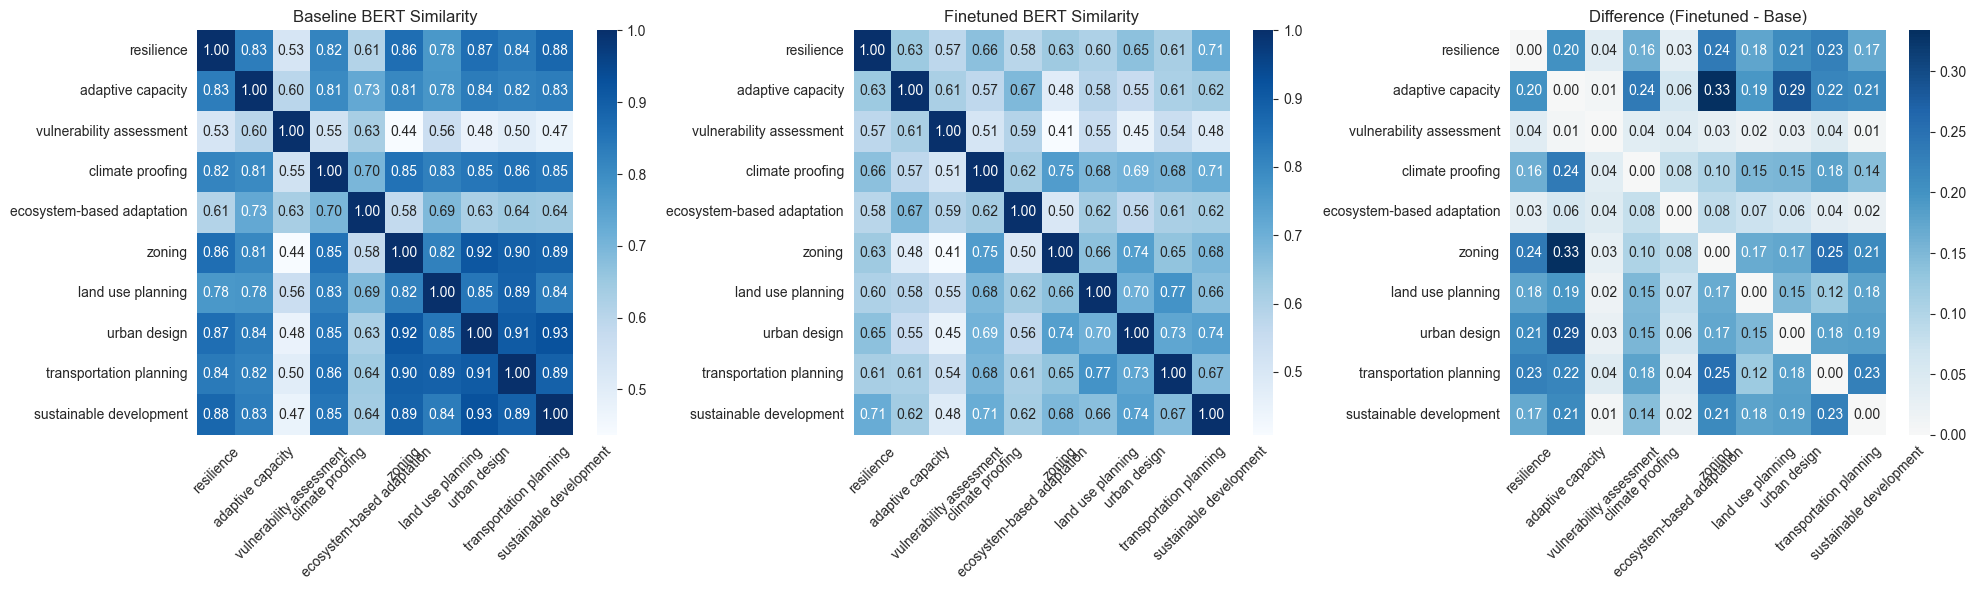

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(cos_sim_base_df, ax=axes[0], cmap="Blues", annot=True, fmt=".2f")
axes[0].set_title("Baseline BERT Similarity")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cos_sim_df_norm, ax=axes[1], cmap="Blues", annot=True, fmt=".2f")
axes[1].set_title("Finetuned BERT Similarity")
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(cos_sim_diff_abs, ax=axes[2], cmap="RdBu", center=0, annot=True, fmt=".2f")
axes[2].set_title("Difference (Finetuned - Base)")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [56]:
cos_sim_diff_abs

,resilience,adaptive capacity,vulnerability assessment,climate proofing,ecosystem-based adaptation,zoning,land use planning,urban design,transportation planning,sustainable development
resilience,3.576279e-07,2.030617e-01,3.989995e-02,0.161877,0.031780,2.360492e-01,1.756867e-01,0.211101,0.229466,1.704832e-01
adaptive capacity,2.030617e-01,5.960464e-08,8.563638e-03,0.236685,0.058404,3.337806e-01,1.946409e-01,0.287114,0.219341,2.115703e-01
vulnerability assessment,3.989995e-02,8.563638e-03,1.192093e-07,0.036659,0.042141,2.903533e-02,1.741767e-02,0.025717,0.042343,9.216100e-03
climate proofing,1.618768e-01,2.366847e-01,3.665888e-02,0.000000,0.079586,1.036714e-01,1.496981e-01,0.152369,0.178920,1.424428e-01
ecosystem-based adaptation,3.177953e-02,5.840445e-02,4.214084e-02,0.079586,0.000000,8.361071e-02,7.067525e-02,0.062342,0.035381,2.488804e-02
zoning,2.360492e-01,3.337806e-01,2.903533e-02,0.103671,0.083611,3.576279e-07,1.689149e-01,0.172280,0.250883,2.129222e-01
land use planning,1.756867e-01,1.946409e-01,1.741767e-02,0.149698,0.070675,1.689149e-01,7.152557e-07,0.149617,0.120311,1.787867e-01
urban design,2.111011e-01,2.871144e-01,2.571669e-02,0.152369,0.062342,1.722798e-01,1.496168e-01,0.000000,0.182050,1.850196e-01
transportation planning,2.294661e-01,2.193413e-01,4.234266e-02,0.178920,0.035381,2.508832e-01,1.203106e-01,0.182050,0.000000,2.282114e-01
sustainable development,1.704832e-01,2.115703e-01,9.216100e-03,0.142443,0.024888,2.129222e-01,1.787867e-01,0.185020,0.228211,2.384186e-07


In [58]:
# 假设 distance_df_difference_normalized 是行列都是概念，值是数值的 DataFrame

df_melted = cos_sim_diff_abs.reset_index().melt(id_vars='index')
df_melted.columns = ['Concept A', 'Concept B', 'Co-occurrence Score']
frequent_itemsets = []
# 遍历每一行，提取概念对和对应的支持度
for _, row in df_melted.iterrows():
    itemset = (row['Concept A'], row['Concept B'])
    support = row['Co-occurrence Score']
    frequent_itemsets.append((itemset, support))

In [59]:
frequent_itemsets

[(('resilience', 'resilience'), 3.5762786865234375e-07),
 (('adaptive capacity', 'resilience'), 0.20306169986724854),
 (('vulnerability assessment', 'resilience'), 0.03989994525909424),
 (('climate proofing', 'resilience'), 0.16187679767608643),
 (('ecosystem-based adaptation', 'resilience'), 0.03177952766418457),
 (('zoning', 'resilience'), 0.23604923486709595),
 (('land use planning', 'resilience'), 0.17568671703338623),
 (('urban design', 'resilience'), 0.21110105514526367),
 (('transportation planning', 'resilience'), 0.22946614027023315),
 (('sustainable development', 'resilience'), 0.17048323154449463),
 (('resilience', 'adaptive capacity'), 0.20306169986724854),
 (('adaptive capacity', 'adaptive capacity'), 5.960464477539063e-08),
 (('vulnerability assessment', 'adaptive capacity'), 0.008563637733459473),
 (('climate proofing', 'adaptive capacity'), 0.2366846799850464),
 (('ecosystem-based adaptation', 'adaptive capacity'), 0.05840444564819336),
 (('zoning', 'adaptive capacity')

# GRAPH

Updated edge widths (non-zero):  [0.20306169986724854, 0.03989994525909424, 0.16187679767608643, 0.03177952766418457, 0.23604923486709595, 0.17568671703338623, 0.21110105514526367, 0.22946614027023315, 0.17048323154449463, 0.008563637733459473, 0.2366846799850464, 0.05840444564819336, 0.33378058671951294, 0.19464093446731567, 0.28711438179016113, 0.21934133768081665, 0.21157032251358032, 0.0366588830947876, 0.042140841484069824, 0.029035329818725586, 0.01741766929626465, 0.025716692209243774, 0.0423426628112793, 0.009216099977493286, 0.07958614826202393, 0.10367143154144287, 0.14969807863235474, 0.15236908197402954, 0.17892003059387207, 0.14244282245635986, 0.08361071348190308, 0.07067525386810303, 0.06234210729598999, 0.035381436347961426, 0.024888038635253906, 0.16891485452651978, 0.17227983474731445, 0.25088322162628174, 0.21292221546173096, 0.14961683750152588, 0.12031060457229614, 0.17878669500350952, 0.18204987049102783, 0.1850196123123169, 0.2282114028930664]
sizes:[0.4366097748

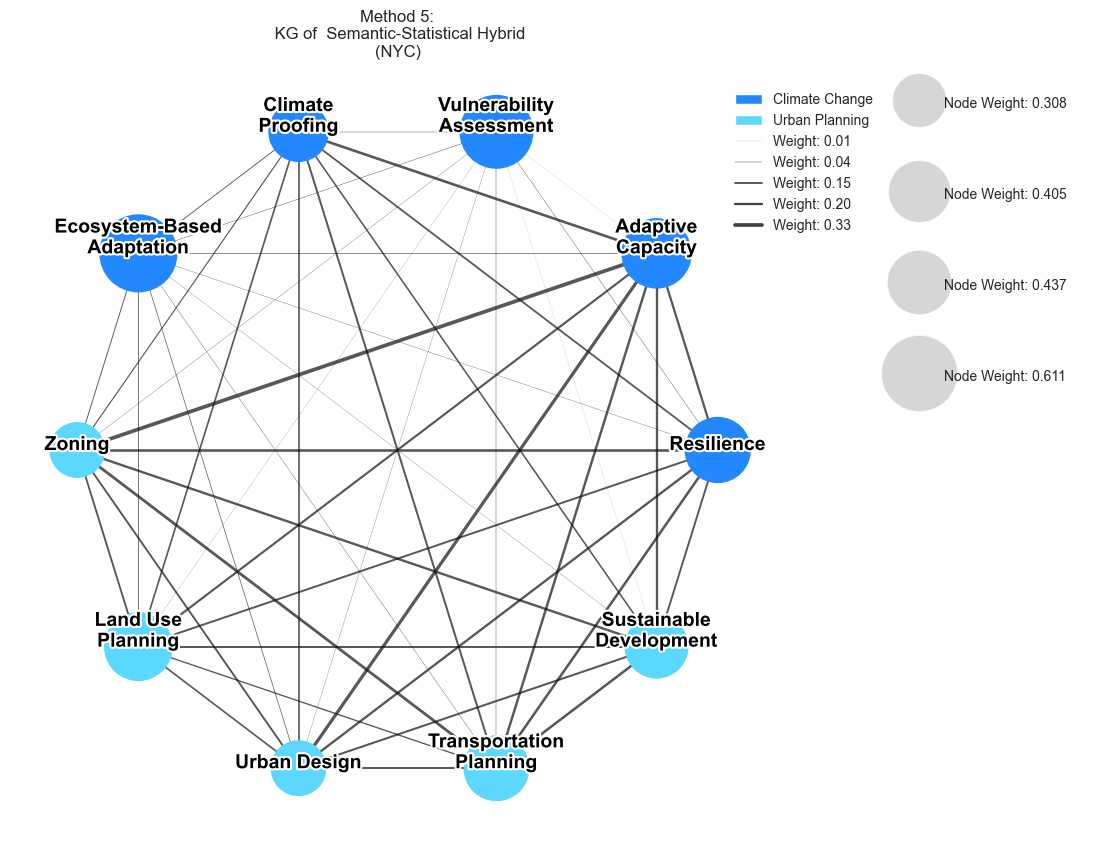

In [74]:
import textwrap
import networkx as nx
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 根据频繁项集构建共现关系图
G = nx.Graph()

# 1. 添加所有节点
for topic in topic_weights:
    G.add_node(topic)

# 2. 添加所有边
for (u, v), freq in frequent_itemsets:
    if u != v:
        G.add_edge(u, v, weight=freq)
# 3. （可选）按节点大小阈值来剔除部分边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    if np.isnan(size) or size < threshold:
        for neigh in list(G.neighbors(node)):
            G.remove_edge(node, neigh)

# 4. 获取剩余边并绘制
edges = list(G.edges(data=True))
edge_widths = [data['weight'] for _, _, data in edges if data['weight'] > 0]

# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=5000
j=8


###############
#####Nodes#####
###############
# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes)[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)
# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes)[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###############
######Edge#####
###############
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.7,
)
###############

# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 保证是 list or numpy array
weights1_array = np.array(weights1)

# 分位点（0%, 25%, 50%, 75%, 100%）
quantiles = np.quantile(weights1_array, [0, 0.25, 0.5, 0.75, 1.0])

# 从 weights1 中找出与每个 quantile 最接近的实际值
example_weights = [weights1_array[np.argmin(np.abs(weights1_array - q))] for q in quantiles]
example_widths = [w * j for w in example_weights]


# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 5

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights[:], example_widths[:]):
#for w, width in zip(example_weights[2:], example_widths[2:]): # ***这个可以设置看几个edge weight
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.2f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    #labelspacing=1.2,
    frameon=False,
    borderpad=1.5    # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=5,  #1.2 # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 5:\n KG of  Semantic-Statistical Hybrid\n(NYC)")
plt.axis('off')
plt.show()

Updated edge widths (non-zero):  [0.20306169986724854, 0.03989994525909424, 0.16187679767608643, 0.03177952766418457, 0.23604923486709595, 0.17568671703338623, 0.21110105514526367, 0.22946614027023315, 0.17048323154449463, 0.008563637733459473, 0.2366846799850464, 0.05840444564819336, 0.33378058671951294, 0.19464093446731567, 0.28711438179016113, 0.21934133768081665, 0.21157032251358032, 0.0366588830947876, 0.042140841484069824, 0.029035329818725586, 0.01741766929626465, 0.025716692209243774, 0.0423426628112793, 0.009216099977493286, 0.07958614826202393, 0.10367143154144287, 0.14969807863235474, 0.15236908197402954, 0.17892003059387207, 0.14244282245635986, 0.08361071348190308, 0.07067525386810303, 0.06234210729598999, 0.035381436347961426, 0.024888038635253906, 0.16891485452651978, 0.17227983474731445, 0.25088322162628174, 0.21292221546173096, 0.14961683750152588, 0.12031060457229614, 0.17878669500350952, 0.18204987049102783, 0.1850196123123169, 0.2282114028930664]
sizes:[0.4412769  0

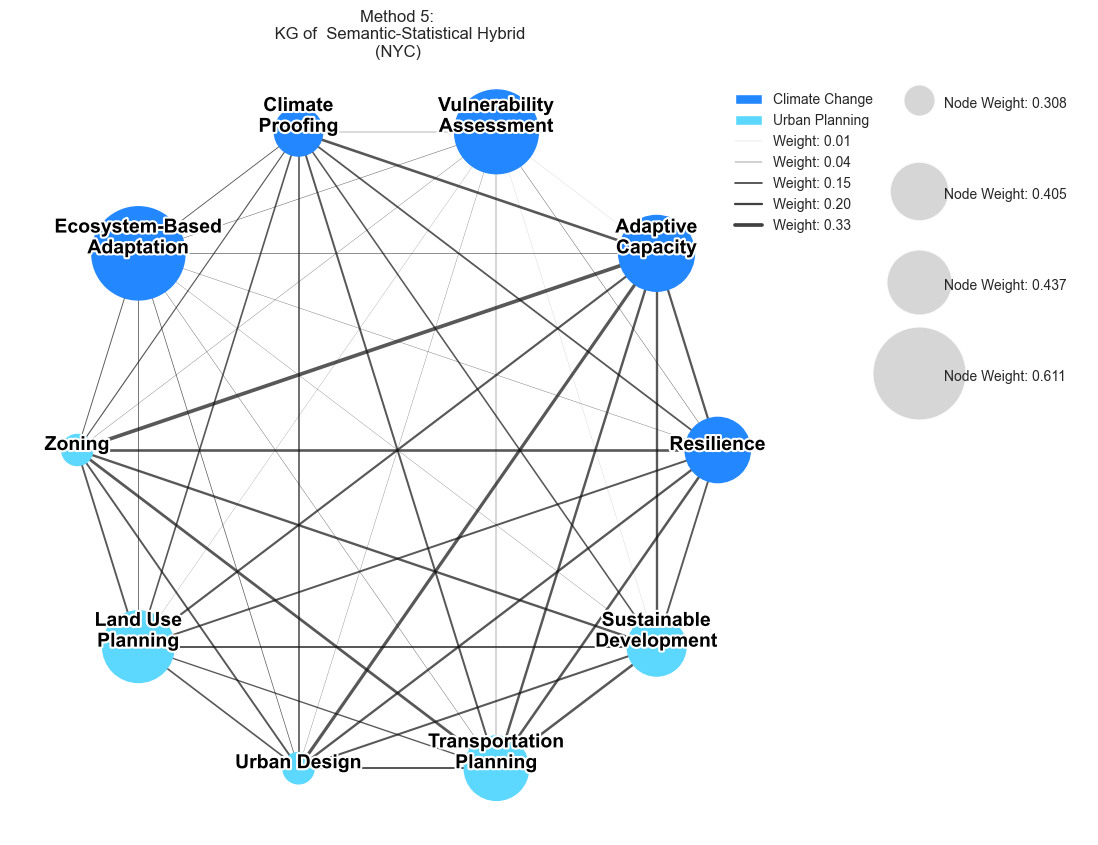

In [75]:
import textwrap
import networkx as nx
import matplotlib.patheffects as path_effects
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 根据频繁项集构建共现关系图
G = nx.Graph()

# 1. 添加所有节点
for topic in topic_weights:
    G.add_node(topic)

# 2. 添加所有边
for (u, v), freq in frequent_itemsets:
    if u != v:
        G.add_edge(u, v, weight=freq)
# 3. （可选）按节点大小阈值来剔除部分边
threshold = 0.0001
for node, size in zip(topic_weights.keys(), sizes):
    if np.isnan(size) or size < threshold:
        for neigh in list(G.neighbors(node)):
            G.remove_edge(node, neigh)

# 4. 获取剩余边并绘制
edges = list(G.edges(data=True))
edge_widths = [data['weight'] for _, _, data in edges if data['weight'] > 0]

# 打印更新后的边宽度
print("Updated edge widths (non-zero): ", edge_widths)

# 圆形布局
pos = nx.circular_layout(G)  # 使用圆形布局
np.random.seed(42)
plt.figure(figsize=(10, 10))
k=5000
j=8

import numpy as np

# 原始权重（0~1区间）
raw_weights = np.array(list(topic_weights.values()))
raw_weights = np.nan_to_num(raw_weights, nan=0.0)  # 替换 NaN 为 0

# 将权重线性归一化到 0~1 区间
min_w, max_w = raw_weights.min(), raw_weights.max()
normalized = (raw_weights - min_w) / (max_w - min_w + 1e-8)

# 设定目标可视化范围，比如视觉上 300 到 800 大小
min_size = 0.1
max_size = 0.9
sizes = normalized * (max_size - min_size) + min_size  # 最终 node size

###############
#####Nodes#####
###############

# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes)[:5],  # 前五个节点
    node_color="#2388FF",
    #node_size=sizes[:5],
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)
# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(fixed_nodes)[5:],  # 剩余节点
    node_color="#5CD8FF",
    #node_size = sizes[5:],
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)
print(f'sizes:{sizes}')
###############

###############
######Edge#####
###############
# 绘制权重大于0的边
nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_width * j for edge_width in edge_widths if edge_width >= 0.001],  # 使用非零的边宽
    edge_color='#111111',
    alpha=0.7,
)
###############

# 提取边的权重
edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]

# 保证是 list or numpy array
weights1_array = np.array(weights1)

# 分位点（0%, 25%, 50%, 75%, 100%）
quantiles = np.quantile(weights1_array, [0, 0.25, 0.5, 0.75, 1.0])

# 从 weights1 中找出与每个 quantile 最接近的实际值
example_weights = [weights1_array[np.argmin(np.abs(weights1_array - q))] for q in quantiles]
example_widths = [w * j for w in example_weights]


# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{topic_weights.get(node, 0):.4f}" if topic_weights.get(node, 0) > 0 else "0"
    modified_node = f"{node}"#\n{weight}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 根据绘图的node_size计算半径
# ✅ 用原始的权重来显示 label，不变
legend_node_weights = list(topic_weights.values())
# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 5

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

# 添加边权重示例
for w, width in zip(example_weights[:], example_widths[:]):
#for w, width in zip(example_weights[2:], example_widths[2:]): # ***这个可以设置看几个edge weight
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            label=f"Weight: {w:.2f}"
        )
    )

# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    #labelspacing=1.2,
    frameon=False,
    borderpad=1.5    # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=5,  #1.2 # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.title("Method 5:\n KG of  Semantic-Statistical Hybrid\n(NYC)")
plt.axis('off')
plt.show()